# 8.8. Detecting hidden structures in a dataset with clustering

In [1]:
from itertools import permutations
import numpy as np
import sklearn
import sklearn.decomposition as dec
import sklearn.cluster as clu
import sklearn.datasets as ds
import sklearn.model_selection as ms
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
X, y = ds.make_blobs(n_samples=200,
                     n_features=2,
                     centers=3,
                     cluster_std=1.5,
                     )

In [4]:
def relabel(cl):
    """Relabel a clustering with three clusters
    to match the original classes."""
    if np.max(cl) != 2:
        return cl
    perms = np.array(list(permutations((0, 1, 2))))
    i = np.argmin([np.sum(np.abs(perm[cl] - y))
                   for perm in perms])
    p = perms[i]
    return p[cl]

In [5]:
def display_clustering(labels, title):
    """Plot the data points with the cluster
    colors."""

    # We relabel the classes when there are 3 clusters
    labels = relabel(labels)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                             sharey=True)
    # Display the points with the true labels on the
    # left, and with the clustering labels on the
    # right.
    for ax, c, title in zip(
            axes,
            [y, labels],
            ["True labels", title]):
        ax.scatter(X[:, 0], X[:, 1], c=c, s=30,
                   linewidths=0, cmap=plt.cm.rainbow)
        ax.set_title(title)

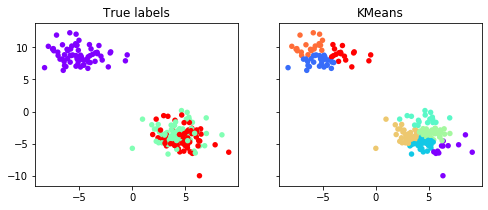

In [7]:
km = clu.KMeans()
km.fit(X)
display_clustering(km.labels_, "KMeans")

## Try different values of number of clusters

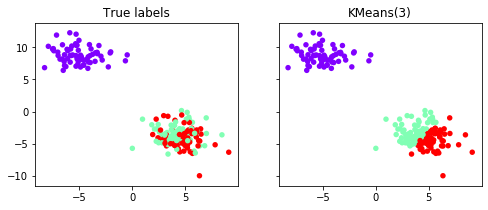

In [8]:
km = clu.KMeans(n_clusters=3)
km.fit(X)
display_clustering(km.labels_, "KMeans(3)")

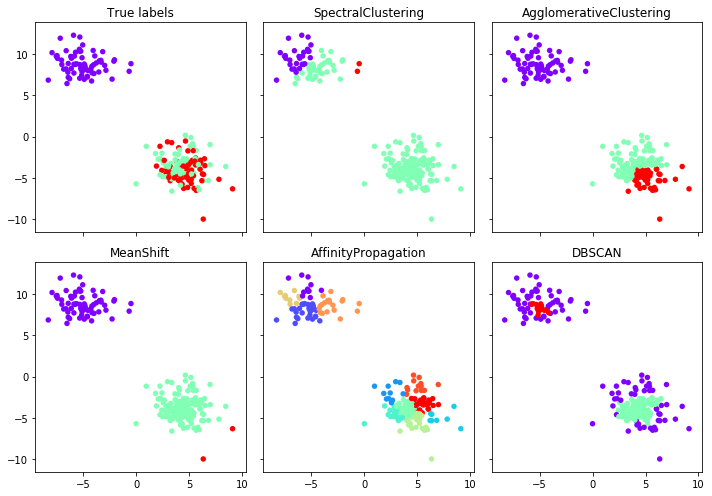

In [9]:
fig, axes = plt.subplots(2, 3,
                         figsize=(10, 7),
                         sharex=True,
                         sharey=True)

axes[0, 0].scatter(X[:, 0], X[:, 1],
                   c=y, s=30,
                   linewidths=0,
                   cmap=plt.cm.rainbow)
axes[0, 0].set_title("True labels")

for ax, est in zip(axes.flat[1:], [
    clu.SpectralClustering(3),
    clu.AgglomerativeClustering(3),
    clu.MeanShift(),
    clu.AffinityPropagation(),
    clu.DBSCAN(),
]):
    est.fit(X)
    c = relabel(est.labels_)
    ax.scatter(X[:, 0], X[:, 1], c=c, s=30,
               linewidths=0, cmap=plt.cm.rainbow)
    ax.set_title(est.__class__.__name__)

# Fix the spacing between subplots.
fig.tight_layout()

### Predictions and Evaluations

In [10]:
pred = km.predict(X)
from sklearn.metrics import classification_report, confusion_matrix

print(pred)

print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[2 0 1 1 0 0 1 2 2 2 2 2 1 0 1 0 1 0 0 0 1 2 1 0 2 0 1 1 0 0 0 2 1 1 1 1 0
 2 1 2 2 0 2 1 2 0 2 1 0 0 0 0 0 2 1 1 2 2 1 1 2 1 0 2 1 0 0 0 2 2 1 1 2 1
 2 2 1 0 0 1 1 1 2 2 2 1 0 1 0 2 1 2 0 2 1 2 0 1 1 0 1 1 0 2 1 2 2 2 1 2 1
 1 1 0 0 2 2 2 0 2 2 0 2 2 0 1 2 0 2 1 0 2 1 1 2 0 1 0 0 0 0 0 0 0 2 0 1 0
 0 0 0 2 0 1 1 0 0 2 0 2 1 2 0 2 1 2 1 0 2 2 1 2 1 1 2 1 1 0 1 0 0 1 2 0 1
 1 0 0 1 0 2 2 1 2 2 1 2 1 2 0]
[[ 0 67  0]
 [43  0 24]
 [24  0 42]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        67
           1       0.00      0.00      0.00        67
           2       0.64      0.64      0.64        66

    accuracy                           0.21       200
   macro avg       0.21      0.21      0.21       200
weighted avg       0.21      0.21      0.21       200



### Choose good value of K

Text(0, 0.5, 'Error Rate')

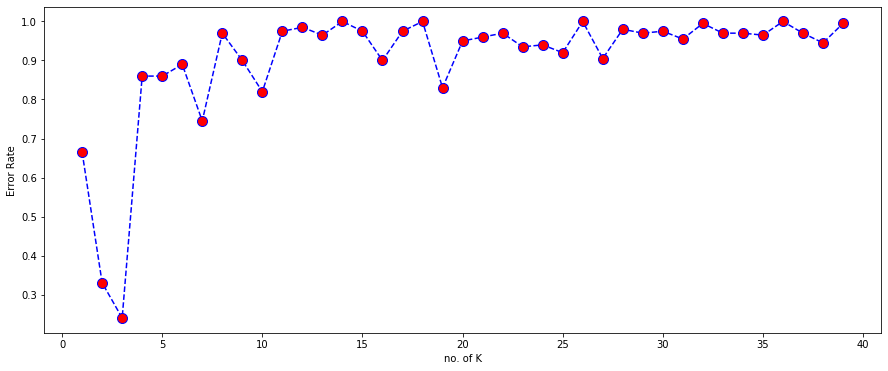

In [11]:
import numpy as np
error_rate = []
for i in range(1,40):
    knn = clu.KMeans(n_clusters = i)
    knn.fit(X, y)
    pred_i = knn.predict(X)
    error_rate.append(np.mean(pred_i != y))
    
plt.figure(figsize=(15,6))
plt.plot(range(1,40),error_rate,color='blue',linestyle='dashed',marker='o', markerfacecolor='red', markersize='10')
plt.xlabel('no. of K')
plt.ylabel('Error Rate')

## Retrain with new K Value

**Retrain your model with the best K value (up to you to decide what you want) and re-do the classification report and the confusion matrix.**

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 2)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))